In [ ]:
#!pip -q install -U "torch>=2.1" "transformers>=4.40" "datasets>=2.18" "huggingface_hub>=0.23" "scipy>=1.11" "tqdm>=4.66" "accelerate>=0.30"


In [ ]:
#!pip install --upgrade --force-reinstall torchvision

#Подготовка данных, базовые энкодеры и ансамбль

In [ ]:
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, T5EncoderModel, get_cosine_schedule_with_warmup
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [ ]:
stsb = load_dataset("PhilipMay/stsb_multi_mt", "ru")     # train/dev/test
sts22 = load_dataset("mteb/sts22-crosslingual-sts", "ru") # test

def _find_first(existing: List[str], candidates: List[str]) -> Optional[str]:
    for c in candidates:
        if c in existing:
            return c
    return None

def infer_sts_columns(ds_split) -> Tuple[str, str, str]:
    cols = list(ds_split.features.keys())
    s1 = _find_first(cols, ["sentence1", "sent1", "s1", "text1", "text_1", "premise"])
    s2 = _find_first(cols, ["sentence2", "sent2", "s2", "text2", "text_2", "hypothesis"])
    y  = _find_first(cols, ["score", "label", "similarity_score", "similarity", "sts_score"])
    if not (s1 and s2 and y):
        raise ValueError(f"Cannot infer STS columns, cols={cols}")
    return s1, s2, y

stsb_s1, stsb_s2, stsb_y = infer_sts_columns(stsb["train"])
sts22_s1, sts22_s2, sts22_y = infer_sts_columns(sts22["test"])

print("STSB cols:", (stsb_s1, stsb_s2, stsb_y))
print("STS22 cols:", (sts22_s1, sts22_s2, sts22_y))

README.md: 0.00B [00:00, ?B/s]

ru/train-00000-of-00001.parquet:   0%|          | 0.00/721k [00:00<?, ?B/s]

ru/test-00000-of-00001.parquet:   0%|          | 0.00/158k [00:00<?, ?B/s]

ru/dev-00000-of-00001.parquet:   0%|          | 0.00/209k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

...

Generating dev split:   0%|          | 0/1500 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

test/ru.jsonl.gz:   0%|          | 0.00/496k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/265 [00:00<?, ? examples/s]

STSB cols: ('sentence1', 'sentence2', 'similarity_score')
STS22 cols: ('sentence1', 'sentence2', 'score')


### Базовый класс энкодеров и метрика

In [ ]:
def sts_quality(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    p = pearsonr(y_true, y_pred)[0]
    s = spearmanr(y_true, y_pred)[0]
    return float((p + s) / 2.0)

@dataclass
class EncoderCfg:
    model_name: str
    pooling: str = "mean"   # "mean" | "cls"
    max_length: int = 256
    normalize: bool = True
    batch_size: int = 32
    trust_remote_code: bool = False  # True, если модель требует custom code

class TextEncoder:
    """
    Универсальный encoder.
    Для BGE-M3 mean vs cls.
    """
    def __init__(self, cfg: EncoderCfg):
        self.cfg = cfg
        self.tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, use_fast=True, trust_remote_code=cfg.trust_remote_code)

        if cfg.model_name == "ai-forever/FRIDA":
            self.model = T5EncoderModel.from_pretrained("ai-forever/FRIDA")
        elif cfg.model_name == "Gameselo/STS-multilingual-mpnet-base-v2":
            from sentence_transformers import SentenceTransformer
            self.model = SentenceTransformer("Gameselo/STS-multilingual-mpnet-base-v2")
        else:
            self.model = AutoModel.from_pretrained(cfg.model_name, trust_remote_code=cfg.trust_remote_code)

        # DataParallel для multi-GPU
        if torch.cuda.device_count() > 1:
            print(f"Using {torch.cuda.device_count()} GPUs")
            self.model = nn.DataParallel(self.model)

        self.model.to(device)
        self.model.eval()

    @torch.inference_mode()
    def encode(self, texts: List[str]) -> torch.Tensor:
        all_emb = []
        bs = self.cfg.batch_size
        for i in tqdm(range(0, len(texts), bs), desc=f"encode[{self.cfg.model_name}|{self.cfg.pooling}]"):
            batch = texts[i:i+bs]
            tok = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=self.cfg.max_length,
                return_tensors="pt",
            ).to(device)

            out = self.model(**tok)
            h = out.last_hidden_state  # [B, T, H]
            attn = tok["attention_mask"].unsqueeze(-1)  # [B, T, 1]

            if self.cfg.pooling == "cls":
                emb = h[:, 0, :]
            elif self.cfg.pooling == "mean":
                summed = (h * attn).sum(dim=1)
                denom = attn.sum(dim=1).clamp(min=1)
                emb = summed / denom
            else:
                raise ValueError(f"Unknown pooling={self.cfg.pooling}")

            if self.cfg.normalize:
                emb = F.normalize(emb, p=2, dim=-1)

            all_emb.append(emb.detach().cpu())

        return torch.cat(all_emb, dim=0)

def cosine_sim(a: torch.Tensor, b: torch.Tensor) -> np.ndarray:
    # Convert to float32 before calling .numpy() to handle bfloat16 compatibility
    return (a * b).sum(dim=-1).float().numpy()

def eval_encoder_on_dataset(enc: TextEncoder, ds_split, s1_col, s2_col, y_col) -> float:
    s1 = [x[s1_col] for x in ds_split]
    s2 = [x[s2_col] for x in ds_split]
    y  = np.array([float(x[y_col]) for x in ds_split], dtype=np.float32)

    e1 = enc.encode(s1)
    e2 = enc.encode(s2)
    pred = cosine_sim(e1, e2)
    return sts_quality(y, pred)

## Ансамбль

Используем предсказания моделей на STSB/STS22 и строим ансамбли:

1. **simple (mean)** — простое среднее предсказаний.
2. **standardized (zmean)** — каждое предсказание стандартизуется (по своим среднему и СКО), потом усредняется.
3. **ranked (rank_mean)** — усреднение по рангам предсказаний (ранжируем и усредняем нормированные ранги).

Ансамбли строятся отдельно для STSB и STS22.

In [ ]:

# Конфигурация всех базовых моделей
BASE_MODELS = {
   # "m-E5-large":           EncoderCfg("intfloat/multilingual-e5-large"),
    "m-E5-large-instruct":  EncoderCfg("intfloat/multilingual-e5-large-instruct"),
   # "BGE-M3-mean":          EncoderCfg("deepvk/USER-bge-m3"),
    "BGE-M3-cls":           EncoderCfg("deepvk/USER-bge-m3", pooling="cls"),
    # дополнительные (используются только в ансамбле оценок, не совместимы для слияния)
   # "DeepPavlov/RuBERT":    EncoderCfg("DeepPavlov/rubert-base-cased-sentence", pooling="cls"),
   # "Ru-LaBSE-sts":         EncoderCfg("sergeyzh/LaBSE-ru-sts", pooling="cls"),
   # "FRIDA":                EncoderCfg("sergeyzh/rubert-mini-frida"),
   # "RoSBERTa":             EncoderCfg("ai-forever/ru-en-RoSBERTa"),
    "Qwen3-Embedding-8B": EncoderCfg("Qwen/Qwen3-Embedding-8B"),
}

def eval_all_base_models():
    rows = []
    for name, cfg in BASE_MODELS.items():
        enc = TextEncoder(cfg)
        q_stsb = eval_encoder_on_dataset(enc, stsb["test"], stsb_s1, stsb_s2, stsb_y)
        q_sts22 = eval_encoder_on_dataset(enc, sts22["test"], sts22_s1, sts22_s2, sts22_y)
        rows.append((name, q_stsb, q_sts22, (q_stsb + q_sts22) / 2))
    return rows


In [ ]:
def ensemble_scores(scores: Dict[str, np.ndarray], mode: str = "rank_mean") -> np.ndarray:
    names = list(scores.keys())
    mat = np.vstack([scores[n] for n in names])  # [M, N]

    if mode == "mean":
        return mat.mean(axis=0)

    if mode == "zmean":
        mu = mat.mean(axis=1, keepdims=True)
        sd = mat.std(axis=1, keepdims=True) + 1e-8
        return ((mat - mu) / sd).mean(axis=0)

    if mode == "rank_mean":
        ranks = np.argsort(np.argsort(mat, axis=1), axis=1).astype(np.float32)
        return ranks.mean(axis=0)

    raise ValueError(mode)

def get_scores_for_models(model_cfgs: Dict[str, EncoderCfg], ds_split, s1_col, s2_col) -> Dict[str, np.ndarray]:
    s1 = [x[s1_col] for x in ds_split]
    s2 = [x[s2_col] for x in ds_split]
    out = {}
    for name, cfg in model_cfgs.items():
        enc = TextEncoder(cfg)
        e1 = enc.encode(s1)
        e2 = enc.encode(s2)
        out[name] = cosine_sim(e1, e2)
    return out

def demo_ensemble():
    pair = {
        "m-E5-large": BASE_MODELS["m-E5-large"],
        "BGE-M3-cls": BASE_MODELS["BGE-M3-cls"],
    }
    scores_stsb = get_scores_for_models(pair, stsb["test"], stsb_s1, stsb_s2)
    scores_sts22 = get_scores_for_models(pair, sts22["test"], sts22_s1, sts22_s2)

    y_stsb = np.array([float(x[stsb_y]) for x in stsb["test"]], dtype=np.float32)
    y_sts22 = np.array([float(x[sts22_y]) for x in sts22["test"]], dtype=np.float32)

    for mode in ["mean", "zmean", "rank_mean"]:
        p1 = ensemble_scores(scores_stsb, mode=mode)
        p2 = ensemble_scores(scores_sts22, mode=mode)
        print(mode, "STSB:", sts_quality(y_stsb, p1), "STS22:", sts_quality(y_sts22, p2))

In [ ]:
demo_ensemble()

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

...

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

encode[deepvk/USER-bge-m3|cls]:   0%|          | 0/9 [00:00<?, ?it/s]

encode[deepvk/USER-bge-m3|cls]:   0%|          | 0/9 [00:00<?, ?it/s]

mean STSB: 0.834706445401704 STS22: 0.6802790623821565
zmean STSB: 0.8351525001536824 STS22: 0.678028636759298
rank_mean STSB: 0.8371102280091005 STS22: 0.6801887294235873



---

# Часть 2. Слияние весов моделей: SLERP, TIES-Merging, DARE

В первой части ноутбука мы рассматривали **ансамбли над оценками релевантности**: каждая модель
отдельно кодирует тексты, мы считаем косинусы и затем усредняем (simple / standardized / ranked).
На практике такой подход требует держать в памяти и прогонять текст через **2+ модели** — дорого.

Альтернатива — **слияние самих параметров** в одну модель. Получаем **одну сеть**, быстрее
ансамбля, но часто точнее каждой из исходных.

Мы реализуем три метода:

1. **SLERP** — сферическая линейная интерполяция двух наборов весов.
   $$\theta_{\text{merged}} = \frac{\sin((1-t)\Omega)}{\sin \Omega}\,\theta_1 + \frac{\sin(t\Omega)}{\sin \Omega}\,\theta_2$$
   где $\Omega$ — угол между $\theta_1$ и $\theta_2$. Сохраняет норму векторов параметров лучше,
   чем линейная интерполяция. Именно этот метод использует ru-en-RoSBERTa для слияния двух
   инициализаций (ruRoBERTa и RoBERTa).

2. **TIES-Merging** (Yadav et al., 2023) — разреженное слияние дельт:
   **Trim** (оставить top-k% по модулю) → **Elect sign** (голосование знаков) → **Disjoint merge**
   (усреднение только согласованных по знаку значений).

3. **DARE** (Yu et al., 2023) — *Drop And REscale*: случайное зануление $p$ доли дельт
   с перемасштабированием оставшихся на $1/(1-p)$. Применяется как предобработка **перед**
   SLERP/TIES, чтобы снять шум файнтюнинга.

### Совместимость архитектур

Слияние весов имеет смысл только если модели имеют **одинаковый бэкбон**.
В нашем зоопарке:

| Модель | Backbone | Совместима для слияния? |
|---|---|---|
| `multilingual-e5-large` | XLM-RoBERTa-large | ✅ |
| `multilingual-e5-large-instruct` | XLM-RoBERTa-large | ✅ |
| `USER-bge-m3` (BGE-M3) | XLM-RoBERTa-large | ✅ |
| `LaBSE-ru-sts` | BERT-base | ❌ (отдельное семейство) |
| `FRIDA` | T5-encoder | ❌ |
| `RoSBERTa` | RoBERTa-base-ru | ❌ |
| `Qwen3-Embedding-0.6B` | Qwen3 | ❌ |

Мы будем сливать тройку из XLM-R-large: **mE5-large**, **mE5-large-instruct**, **BGE-M3**.
Для TIES общим «родителем» берём `FacebookAI/xlm-roberta-large`.


## 2.1 Конфигурация моделей-кандидатов для слияния

In [ ]:

# На всякий случай убедимся, что BASE_MODELS определён (в исходном ноутбуке он задаётся
# в ячейке с eval_all_base_models). Если он уже есть — не перезаписываем.
try:
    BASE_MODELS  # noqa
except NameError:
    BASE_MODELS = {
        "m-E5-large":           EncoderCfg("intfloat/multilingual-e5-large"),
        "m-E5-large-instruct":  EncoderCfg("intfloat/multilingual-e5-large-instruct"),
        "BGE-M3-mean":          EncoderCfg("deepvk/USER-bge-m3"),
        "BGE-M3-cls":           EncoderCfg("deepvk/USER-bge-m3", pooling="cls"),
    }

# HF-пути моделей, которые мы будем сливать (XLM-R-large совместимые)
MERGE_CANDIDATES = {
    "mE5-large":          "intfloat/multilingual-e5-large",
    "mE5-large-instruct": "intfloat/multilingual-e5-large-instruct",
    "BGE-M3":             "deepvk/USER-bge-m3",
}

# Общий «родитель» — тот претрен, из которого инициализированы все три
XLMR_BASE = "FacebookAI/xlm-roberta-large"

# Список пар, которые будем сливать
MERGE_PAIRS = [
    ("mE5-large",          "BGE-M3"),
    ("mE5-large-instruct", "BGE-M3"),
    ("mE5-large",          "mE5-large-instruct"),
]
print("Будут сливаться пары:", MERGE_PAIRS)


Будут сливаться пары: [('mE5-large', 'BGE-M3'), ('mE5-large-instruct', 'BGE-M3'), ('mE5-large', 'mE5-large-instruct')]



## 2.2 Инфраструктура слияния весов

Базовые операции:
- **Загрузка `state_dict`** на CPU в fp32 (экономим GPU-память).
- **Поиск совпадающих ключей**: одинаковые имена параметров + одинаковые формы.
- **Сборка `TextEncoder` с подменой весов** — чтобы переиспользовать уже готовую логику оценки.


In [ ]:

import gc
from copy import deepcopy
from transformers import AutoConfig

def load_sd(model_name: str):
    """Загружает state_dict модели на CPU в fp32. Возвращает (state_dict, config)."""
    cfg = AutoConfig.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
    sd = {k: v.detach().cpu().float().clone() for k, v in model.state_dict().items()}
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return sd, cfg

def compatible_keys(sd_a: dict, sd_b: dict) -> list:
    """Возвращает список ключей, которые присутствуют в обоих state_dict и имеют одинаковую форму."""
    common = []
    skipped = []
    for k in sd_a.keys():
        if k in sd_b and sd_a[k].shape == sd_b[k].shape:
            common.append(k)
        else:
            skipped.append(k)
    return common, skipped

def merged_sd_into_encoder(base_hf_name: str, merged_sd: dict, pooling: str = "mean",
                           max_length: int = 256, batch_size: int = 32) -> "TextEncoder":
    """Создаёт TextEncoder, грузит архитектуру base_hf_name и подменяет веса на merged_sd."""
    cfg = EncoderCfg(model_name=base_hf_name, pooling=pooling,
                     max_length=max_length, batch_size=batch_size, normalize=True)
    enc = TextEncoder(cfg)
    # у enc.model может быть DataParallel-обёртка
    target = enc.model.module if isinstance(enc.model, nn.DataParallel) else enc.model
    missing, unexpected = target.load_state_dict(merged_sd, strict=False)
    if missing:
        print(f"[load_state_dict] missing: {len(missing)} keys (e.g. {missing[:3]})")
    if unexpected:
        print(f"[load_state_dict] unexpected: {len(unexpected)} keys (e.g. {unexpected[:3]})")
    target.to(device)
    target.eval()
    return enc



## 2.3 SLERP — сферическая линейная интерполяция

Реализуем **два варианта**:

- **global SLERP**: flatten'им все совместимые веса в один вектор, считаем один общий угол
  $\Omega$, применяем формулу. Минус — разные слои могут быть «развернуты» в разные стороны.
- **per-tensor SLERP** (рекомендуемый, используется в `mergekit`): применяем SLERP отдельно
  для каждого тензора параметров. Намного стабильнее.

Если угол между векторами очень мал ($\sin \Omega \to 0$) — безопасно откатываемся
к обычной линейной интерполяции (LERP), чтобы избежать деления на ноль.

Параметр $t \in [0, 1]$:
- $t = 0$ → полностью $\theta_1$
- $t = 1$ → полностью $\theta_2$
- $t = 0.5$ → «середина по дуге»


In [ ]:

DOT_EPS = 1e-7
SIN_EPS = 1e-6

def _slerp_vectors(v1: torch.Tensor, v2: torch.Tensor, t: float) -> torch.Tensor:
    """SLERP двух 1D-тензоров (или flat-вью). Fallback к LERP при малом sin(omega)."""
    v1f = v1.flatten().double()
    v2f = v2.flatten().double()
    n1 = v1f.norm() + DOT_EPS
    n2 = v2f.norm() + DOT_EPS
    cos_omega = torch.clamp((v1f @ v2f) / (n1 * n2), -1.0 + DOT_EPS, 1.0 - DOT_EPS)
    omega = torch.acos(cos_omega)
    sin_omega = torch.sin(omega)
    if sin_omega.abs() < SIN_EPS:
        # векторы почти коллинеарны — LERP
        merged = (1 - t) * v1f + t * v2f
    else:
        a = torch.sin((1 - t) * omega) / sin_omega
        b = torch.sin(t * omega) / sin_omega
        merged = a * v1f + b * v2f
    return merged.to(v1.dtype).reshape(v1.shape)

def slerp_per_tensor(sd1: dict, sd2: dict, t: float) -> dict:
    """SLERP отдельно для каждого совместимого параметра."""
    common, _ = compatible_keys(sd1, sd2)
    merged = {}
    for k in common:
        v1, v2 = sd1[k], sd2[k]
        # 1D/embeddings/bias — всё равно flatten. Для 0D скаляров — просто lerp.
        if v1.numel() <= 1:
            merged[k] = ((1 - t) * v1.float() + t * v2.float()).to(v1.dtype)
        else:
            merged[k] = _slerp_vectors(v1.float(), v2.float(), t)
    # для не-совпавших ключей берём из sd1 (запасной путь)
    for k in sd1:
        if k not in merged:
            merged[k] = sd1[k].clone()
    return merged

def slerp_global(sd1: dict, sd2: dict, t: float) -> dict:
    """Глобальный SLERP: все совместимые веса как один большой вектор, один общий omega."""
    common, _ = compatible_keys(sd1, sd2)
    flats1 = [sd1[k].flatten().double() for k in common]
    flats2 = [sd2[k].flatten().double() for k in common]
    v1 = torch.cat(flats1)
    v2 = torch.cat(flats2)
    merged_flat = _slerp_vectors(v1, v2, t)

    merged = {}
    ptr = 0
    for k in common:
        n = sd1[k].numel()
        merged[k] = merged_flat[ptr:ptr+n].reshape(sd1[k].shape).to(sd1[k].dtype)
        ptr += n
    for k in sd1:
        if k not in merged:
            merged[k] = sd1[k].clone()
    return merged

# Быстрый тест геометрии
def _self_test_slerp():
    torch.manual_seed(0)
    a = {"w": torch.randn(10)}
    b = {"w": torch.randn(10)}
    m0   = slerp_per_tensor(a, b, 0.0)["w"]
    m1   = slerp_per_tensor(a, b, 1.0)["w"]
    m05  = slerp_per_tensor(a, b, 0.5)["w"]
    assert torch.allclose(m0, a["w"], atol=1e-4), "t=0 должен давать theta_1"
    assert torch.allclose(m1, b["w"], atol=1e-4), "t=1 должен давать theta_2"
    # норма merged примерно между нормами исходных (свойство SLERP)
    print("||a||=", a["w"].norm().item(),
          "||b||=", b["w"].norm().item(),
          "||slerp(0.5)||=", m05.norm().item())
_self_test_slerp()


||a||= 3.4940316677093506 ||b||= 2.651381015777588 ||slerp(0.5)||= 3.084627628326416



## 2.4 TIES-Merging

Идея: дельты файнтюнинга $\tau_k = \theta_k - \theta_{\text{base}}$ содержат много шума
и конфликтов знаков между разными файнтюнами. TIES решает это в три шага:

1. **Trim**: для каждой дельты оставляем только top-`density` долю значений по модулю,
   остальное зануляем.
2. **Elect Sign**: для каждой координаты параметра выбираем итоговый знак как
   $\mathrm{sign}\left(\sum_k \tau_k^{\text{trim}}\right)$ (голосование, взвешенное по магнитуде).
3. **Disjoint Merge**: усредняем по тем моделям, чей знак совпадает с выбранным.

Итоговые веса: $\theta_{\text{merged}} = \theta_{\text{base}} + \lambda \cdot \tilde\tau$,
где $\lambda$ — масштаб (обычно $\lambda \in [0.8, 1.2]$).

**Важно**: TIES требует общей `base` модели. Мы возьмём `xlm-roberta-large` — родителя
для mE5 и BGE-M3.


In [ ]:

def _trim_by_density(delta: torch.Tensor, density: float) -> torch.Tensor:
    """Оставляет top-density долю значений по |.|; остальное -> 0."""
    if density >= 1.0:
        return delta.clone()
    flat = delta.flatten().abs()
    k = max(1, int(density * flat.numel()))
    if k >= flat.numel():
        return delta.clone()
    # threshold = k-й по величине
    thr = torch.kthvalue(flat, flat.numel() - k + 1).values
    mask = delta.abs() >= thr
    return delta * mask.to(delta.dtype)

def ties_merge(base_sd: dict, ft_sds: list, density: float = 0.4, lamb: float = 1.0) -> dict:
    """TIES-merging: base_sd + lamb * disjoint_merge(trim(delta_k))."""
    # работаем только с ключами, общими для всех
    all_sds = [base_sd] + ft_sds
    common = set(base_sd.keys())
    for sd in ft_sds:
        common &= set(sd.keys())
    common = [k for k in base_sd.keys() if k in common
              and all(sd[k].shape == base_sd[k].shape for sd in ft_sds)]

    merged = {k: base_sd[k].clone() for k in base_sd.keys()}
    for k in common:
        base = base_sd[k].float()
        deltas = [sd[k].float() - base for sd in ft_sds]

        # 1) Trim
        deltas = [_trim_by_density(d, density) for d in deltas]

        # 2) Elect sign (по сумме со знаком)
        stacked = torch.stack(deltas, dim=0)         # [K, ...]
        sign_sum = stacked.sum(dim=0)
        elected_sign = torch.sign(sign_sum)
        # там, где все нули — знак 0 (значит ничего не добавляем)

        # 3) Disjoint merge
        match_mask = (torch.sign(stacked) == elected_sign.unsqueeze(0)).to(stacked.dtype)
        # чтобы не делить на 0, считаем число согласных моделей
        denom = match_mask.sum(dim=0).clamp(min=1.0)
        agreed_mean = (stacked * match_mask).sum(dim=0) / denom
        # финальный тензор
        new_val = base + lamb * agreed_mean
        merged[k] = new_val.to(base_sd[k].dtype)
    return merged



## 2.5 DARE — Drop And REscale

DARE работает с дельтами $\tau = \theta_{\text{ft}} - \theta_{\text{base}}$:
независимо для каждой координаты с вероятностью $p$ зануляет её, а оставшиеся масштабирует
на $1/(1-p)$ (несмещённая оценка).

Полезен как **предобработка** для SLERP/TIES: убирает шум файнтюнинга, сохраняя
средний вклад дельт.

Важный нюанс: DARE сам по себе требует base-модели (потому что работает с дельтами).
В нашем сценарии используем `xlm-roberta-large` как base, применяем DARE к дельтам
mE5 и BGE-M3 → восстанавливаем «очищенные» чекпоинты → кормим их в SLERP или TIES.


In [ ]:

def dare_prune_delta(delta: torch.Tensor, p: float, generator: torch.Generator = None) -> torch.Tensor:
    """Bernoulli drop + rescale для дельты."""
    if p <= 0.0:
        return delta.clone()
    if p >= 1.0:
        return torch.zeros_like(delta)
    mask = torch.bernoulli(torch.full_like(delta, 1.0 - p), generator=generator)
    return delta * mask / (1.0 - p)

def dare_reconstruct(base_sd: dict, ft_sd: dict, p: float, seed: int = 0) -> dict:
    """Возвращает новый state_dict: base + DARE(delta)."""
    g = torch.Generator().manual_seed(seed)
    common, _ = compatible_keys(base_sd, ft_sd)
    new_sd = {k: ft_sd[k].clone() for k in ft_sd.keys()}
    for k in common:
        base = base_sd[k].float()
        delta = ft_sd[k].float() - base
        pruned = dare_prune_delta(delta, p, generator=g)
        new_sd[k] = (base + pruned).to(ft_sd[k].dtype)
    return new_sd



## 2.6 Пайплайн оценки слитых моделей

Для каждой слитой модели мы:
1. Загружаем в `TextEncoder` (и для `mean`, и для `cls` pooling, где это осмысленно).
2. Считаем качество на **STSB-dev** — это наша валидация для подбора гиперпараметров (`t`, `density`, `p`).
3. Финальное качество — на **STSB-test** и **STS22-test**, как в исходном эксперименте.

После эксперимента удаляем модель из GPU, чтобы не забить память.


In [ ]:

def eval_merged_on_bench(enc: "TextEncoder", split: str = "test") -> dict:
    """Возвращает dict с метриками на STSB и STS22 для указанного split."""
    res = {}
    # STSB может иметь dev/test
    if split in stsb:
        res[f"STSB({split})"] = eval_encoder_on_dataset(
            enc, stsb[split], stsb_s1, stsb_s2, stsb_y
        )
    # STS22 обычно только test
    if "test" in sts22 and split == "test":
        res["STS22(test)"] = eval_encoder_on_dataset(
            enc, sts22["test"], sts22_s1, sts22_s2, sts22_y
        )
    if len(res) >= 2:
        res["Mean"] = float(np.mean(list(res.values())))
    return res

def cleanup_encoder(enc):
    try:
        del enc.model
        del enc
    except Exception:
        pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Определим split для валидации SLERP-t (по STSB dev, чтобы не подглядывать в test)
STSB_VAL_SPLIT = "dev" if "dev" in stsb else ("validation" if "validation" in stsb else "test")
print("Используем для валидации SLERP split:", STSB_VAL_SPLIT)


Используем для валидации SLERP split: dev



## 2.7 Предзагрузка `state_dict`'ов кандидатов

Загружаем веса всех кандидатов один раз на CPU, чтобы не качать по сети при каждом эксперименте.
Предупреждение: это займёт несколько GB RAM (три XLM-R-large в fp32 ≈ 3×2.2 GB ≈ 6.6 GB).


In [ ]:

print("Загружаем state_dict кандидатов (один раз, на CPU в fp32)...")
SD_CACHE = {}
CFG_CACHE = {}
for short, hf in MERGE_CANDIDATES.items():
    print(f"  - {short}: {hf}")
    SD_CACHE[short], CFG_CACHE[short] = load_sd(hf)

print("Загружаем base (XLM-R-large) для TIES/DARE...")
SD_BASE, CFG_BASE = load_sd(XLMR_BASE)

# Диагностика: сколько ключей совместимо между mE5 и BGE-M3
common, skipped = compatible_keys(SD_CACHE["mE5-large"], SD_CACHE["BGE-M3"])
print(f"\nСовместимых ключей mE5 vs BGE-M3: {len(common)}")
print(f"Пропущено (несовпадение): {len(skipped)}")
if skipped[:3]:
    print(f"Примеры пропущенных: {skipped[:3]}")

# Также проверим совместимость с base
common_b, skipped_b = compatible_keys(SD_BASE, SD_CACHE["mE5-large"])
print(f"Совместимых ключей XLM-R vs mE5: {len(common_b)}")


Загружаем state_dict кандидатов (один раз, на CPU в fp32)...
  - mE5-large: intfloat/multilingual-e5-large


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  - mE5-large-instruct: intfloat/multilingual-e5-large-instruct


...

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Совместимых ключей mE5 vs BGE-M3: 389
Пропущено (несовпадение): 2
Примеры пропущенных: ['embeddings.word_embeddings.weight', 'embeddings.position_embeddings.weight']
Совместимых ключей XLM-R vs mE5: 391



## 2.8 Baseline: метрики исходных моделей

Переcчитываем метрики одиночных моделей (чтобы было с чем сравнивать слитые). Если уже
считали в первой части — результат ляжет в `baseline_rows`.


In [ ]:

baseline_cfgs = {
    "mE5-large":              EncoderCfg("intfloat/multilingual-e5-large"),
    "mE5-large-instruct":     EncoderCfg("intfloat/multilingual-e5-large-instruct"),
    "BGE-M3-mean":            EncoderCfg("deepvk/USER-bge-m3", pooling="mean"),
    "BGE-M3-cls":             EncoderCfg("deepvk/USER-bge-m3", pooling="cls"),
}

baseline_rows = []
for name, cfg in baseline_cfgs.items():
    enc = TextEncoder(cfg)
    r = eval_merged_on_bench(enc, split="test")
    r["model"] = name
    r["type"]  = "baseline"
    baseline_rows.append(r)
    print(name, r)
    cleanup_encoder(enc)

df_base = pd.DataFrame(baseline_rows)[["model", "type", "STSB(test)", "STS22(test)", "Mean"]]
df_base


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/44 [00:00<?, ?it/s]

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/44 [00:00<?, ?it/s]

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/9 [00:00<?, ?it/s]

...

encode[deepvk/USER-bge-m3|cls]:   0%|          | 0/44 [00:00<?, ?it/s]

encode[deepvk/USER-bge-m3|cls]:   0%|          | 0/9 [00:00<?, ?it/s]

encode[deepvk/USER-bge-m3|cls]:   0%|          | 0/9 [00:00<?, ?it/s]

BGE-M3-cls {'STSB(test)': 0.828284721653388, 'STS22(test)': 0.6776044240777477, 'Mean': 0.7529445728655678, 'model': 'BGE-M3-cls', 'type': 'baseline'}


,model,type,STSB(test),STS22(test),Mean
0,mE5-large,baseline,0.818608,0.662740,0.740674
1,mE5-large-instruct,baseline,0.817467,0.672908,0.745187
2,BGE-M3-mean,baseline,0.833628,0.667160,0.750394
3,BGE-M3-cls,baseline,0.828285,0.677604,0.752945



## 2.9 Эксперимент: SLERP

Подбираем `t` на STSB-dev, затем оцениваем на STSB-test + STS22-test. Для каждой пары делаем
**per-tensor SLERP** (рекомендуемый) + один прогон **global SLERP** для референса.

Слитая модель наследует оба pooling'а (mean/cls). Оценим `mean` — она работает и для mE5,
и для BGE-M3, поэтому это самый честный режим для слитой модели.


In [ ]:

SLERP_T_GRID = [0.3, 0.5, 0.7]

def run_slerp_experiment(name_a: str, name_b: str,
                         hf_base_arch: str,
                         t_grid=SLERP_T_GRID,
                         pooling: str = "mean",
                         also_global: bool = True):
    """Возвращает список словарей-строк таблицы."""
    sd_a = SD_CACHE[name_a]
    sd_b = SD_CACHE[name_b]
    rows = []

    # --- per-tensor SLERP: подбор t на STSB(val)
    best_t, best_val = None, -1e9
    val_scores = {}
    for t in t_grid:
        merged = slerp_per_tensor(sd_a, sd_b, t=t)
        enc = merged_sd_into_encoder(hf_base_arch, merged, pooling=pooling)
        q_val = eval_encoder_on_dataset(enc, stsb[STSB_VAL_SPLIT], stsb_s1, stsb_s2, stsb_y)
        val_scores[t] = q_val
        print(f"  [SLERP per-tensor] {name_a} x {name_b}  t={t:.2f} -> STSB({STSB_VAL_SPLIT})={q_val:.4f}")
        if q_val > best_val:
            best_val, best_t = q_val, t
        cleanup_encoder(enc)

    # финальный прогон на test с лучшим t
    merged_best = slerp_per_tensor(sd_a, sd_b, t=best_t)
    enc = merged_sd_into_encoder(hf_base_arch, merged_best, pooling=pooling)
    r = eval_merged_on_bench(enc, split="test")
    r.update({
        "model": f"SLERP[{name_a} ⨁ {name_b}] (per-tensor, t={best_t})",
        "type":  "slerp_per_tensor",
        "t_best": best_t,
        "val_grid": val_scores,
    })
    rows.append(r)
    print("  >>", r["model"], "| STSB:", r.get("STSB(test)"), "STS22:", r.get("STS22(test)"), "Mean:", r.get("Mean"))
    cleanup_encoder(enc)

    # global SLERP (один прогон, t=0.5)
    if also_global:
        merged_g = slerp_global(sd_a, sd_b, t=0.5)
        enc = merged_sd_into_encoder(hf_base_arch, merged_g, pooling=pooling)
        r = eval_merged_on_bench(enc, split="test")
        r.update({
            "model": f"SLERP[{name_a} ⨁ {name_b}] (global, t=0.5)",
            "type":  "slerp_global",
            "t_best": 0.5,
        })
        rows.append(r)
        print("  >>", r["model"], "| Mean:", r.get("Mean"))
        cleanup_encoder(enc)

    return rows

# Запускаем SLERP для всех наших пар
slerp_rows = []
for a, b in MERGE_PAIRS:
    print(f"\n==== SLERP: {a} ⨁ {b} ====")
    # для архитектуры берём одну из двух моделей (XLM-R-large) — любая подойдёт
    arch = MERGE_CANDIDATES[a]
    slerp_rows += run_slerp_experiment(a, b, hf_base_arch=arch, pooling="mean", also_global=True)



==== SLERP: mE5-large ⨁ BGE-M3 ====


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/47 [00:00<?, ?it/s]

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/47 [00:00<?, ?it/s]

...

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/44 [00:00<?, ?it/s]

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/44 [00:00<?, ?it/s]

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/9 [00:00<?, ?it/s]

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/9 [00:00<?, ?it/s]

  >> SLERP[mE5-large ⨁ mE5-large-instruct] (global, t=0.5) | Mean: 0.757244379927349



## 2.10 Эксперимент: TIES-Merging

TIES-Merging способен объединять **3+ моделей сразу**, поэтому сольём все три наших
файнтюна (mE5-large + mE5-large-instruct + BGE-M3) в одну модель.

Подбираем `density` на STSB(dev). `λ = 1.0`.


In [ ]:

TIES_DENSITY_GRID = [0.2, 0.4, 0.7]

# Сольём все три файнтюна относительно xlm-roberta-large
ft_names = ["mE5-large", "mE5-large-instruct", "BGE-M3"]
ft_sds = [SD_CACHE[n] for n in ft_names]

ties_rows = []
best_t, best_val = None, -1e9
val_scores = {}
for d in TIES_DENSITY_GRID:
    merged = ties_merge(SD_BASE, ft_sds, density=d, lamb=1.0)
    enc = merged_sd_into_encoder(XLMR_BASE, merged, pooling="mean")
    q_val = eval_encoder_on_dataset(enc, stsb[STSB_VAL_SPLIT], stsb_s1, stsb_s2, stsb_y)
    val_scores[d] = q_val
    print(f"[TIES] density={d} -> STSB({STSB_VAL_SPLIT})={q_val:.4f}")
    if q_val > best_val:
        best_val, best_d = q_val, d
    cleanup_encoder(enc)

# финальная оценка с лучшим density
merged = ties_merge(SD_BASE, ft_sds, density=best_d, lamb=1.0)
for pooling in ["mean", "cls"]:
    enc = merged_sd_into_encoder(XLMR_BASE, merged, pooling=pooling)
    r = eval_merged_on_bench(enc, split="test")
    r.update({
        "model": f"TIES[{'+'.join(ft_names)}] (density={best_d}, pooling={pooling})",
        "type":  "ties",
        "density": best_d,
        "val_grid": val_scores,
    })
    ties_rows.append(r)
    print(">>", r["model"], "| Mean:", r.get("Mean"))
    cleanup_encoder(enc)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

encode[FacebookAI/xlm-roberta-large|cls]:   0%|          | 0/44 [00:00<?, ?it/s]

encode[FacebookAI/xlm-roberta-large|cls]:   0%|          | 0/44 [00:00<?, ?it/s]

encode[FacebookAI/xlm-roberta-large|cls]:   0%|          | 0/9 [00:00<?, ?it/s]

encode[FacebookAI/xlm-roberta-large|cls]:   0%|          | 0/9 [00:00<?, ?it/s]

>> TIES[mE5-large+mE5-large-instruct+BGE-M3] (density=0.7, pooling=cls) | Mean: 0.734624850934481



## 2.11 Эксперимент: DARE как предобработка

DARE сам по себе не «сливает» — он чистит дельты. Поэтому комбинируем:
- **DARE → SLERP**: DARE применяется к обеим моделям (дельты от xlm-roberta-large), затем SLERP.
- **DARE → TIES**: DARE применяется к дельтам перед TIES-trim (дополнительная регуляризация).

Подбираем drop-rate `p` на STSB(dev), `t` берём лучший из SLERP-эксперимента (чтобы не
умножать сетку).


In [ ]:

DARE_P_GRID = [0.3, 0.5, 0.7]

# Берём лучший t из SLERP для пары (mE5-large, BGE-M3)
best_t_slerp = None
for r in slerp_rows:
    if r.get("type") == "slerp_per_tensor" and "mE5-large ⨁ BGE-M3" in r["model"]:
        best_t_slerp = r["t_best"]
        break
best_t_slerp = best_t_slerp or 0.5
print(f"Используем t={best_t_slerp} из SLERP-эксперимента для DARE+SLERP.")

dare_rows = []

# ---------- DARE + SLERP ----------
name_a, name_b = "mE5-large", "BGE-M3"
sd_a, sd_b = SD_CACHE[name_a], SD_CACHE[name_b]
val_scores_p = {}
best_p_ss, best_val = None, -1e9
for p in DARE_P_GRID:
    sd_a_d = dare_reconstruct(SD_BASE, sd_a, p=p, seed=1)
    sd_b_d = dare_reconstruct(SD_BASE, sd_b, p=p, seed=2)
    merged = slerp_per_tensor(sd_a_d, sd_b_d, t=best_t_slerp)
    enc = merged_sd_into_encoder(MERGE_CANDIDATES[name_a], merged, pooling="mean")
    q_val = eval_encoder_on_dataset(enc, stsb[STSB_VAL_SPLIT], stsb_s1, stsb_s2, stsb_y)
    val_scores_p[p] = q_val
    print(f"[DARE+SLERP] p={p} -> STSB({STSB_VAL_SPLIT})={q_val:.4f}")
    if q_val > best_val:
        best_val, best_p_ss = q_val, p
    cleanup_encoder(enc)

sd_a_d = dare_reconstruct(SD_BASE, sd_a, p=best_p_ss, seed=1)
sd_b_d = dare_reconstruct(SD_BASE, sd_b, p=best_p_ss, seed=2)
merged = slerp_per_tensor(sd_a_d, sd_b_d, t=best_t_slerp)
enc = merged_sd_into_encoder(MERGE_CANDIDATES[name_a], merged, pooling="mean")
r = eval_merged_on_bench(enc, split="test")
r.update({"model": f"DARE+SLERP[{name_a} ⨁ {name_b}] (p={best_p_ss}, t={best_t_slerp})",
          "type": "dare_slerp", "p": best_p_ss, "t": best_t_slerp, "val_grid": val_scores_p})
dare_rows.append(r)
print(">>", r["model"], "| Mean:", r.get("Mean"))
cleanup_encoder(enc)

# ---------- DARE + TIES ----------
val_scores_p2 = {}
best_p_st, best_val = None, -1e9
for p in DARE_P_GRID:
    ft_sds_dare = [dare_reconstruct(SD_BASE, SD_CACHE[n], p=p, seed=i+1)
                   for i, n in enumerate(ft_names)]
    merged = ties_merge(SD_BASE, ft_sds_dare, density=best_d, lamb=1.0)
    enc = merged_sd_into_encoder(XLMR_BASE, merged, pooling="mean")
    q_val = eval_encoder_on_dataset(enc, stsb[STSB_VAL_SPLIT], stsb_s1, stsb_s2, stsb_y)
    val_scores_p2[p] = q_val
    print(f"[DARE+TIES] p={p} -> STSB({STSB_VAL_SPLIT})={q_val:.4f}")
    if q_val > best_val:
        best_val, best_p_st = q_val, p
    cleanup_encoder(enc)

ft_sds_dare = [dare_reconstruct(SD_BASE, SD_CACHE[n], p=best_p_st, seed=i+1)
               for i, n in enumerate(ft_names)]
merged = ties_merge(SD_BASE, ft_sds_dare, density=best_d, lamb=1.0)
enc = merged_sd_into_encoder(XLMR_BASE, merged, pooling="mean")
r = eval_merged_on_bench(enc, split="test")
r.update({"model": f"DARE+TIES[{'+'.join(ft_names)}] (p={best_p_st}, density={best_d})",
          "type": "dare_ties", "p": best_p_st, "density": best_d, "val_grid": val_scores_p2})
dare_rows.append(r)
print(">>", r["model"], "| Mean:", r.get("Mean"))
cleanup_encoder(enc)


Используем t=0.3 из SLERP-эксперимента для DARE+SLERP.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/47 [00:00<?, ?it/s]

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/47 [00:00<?, ?it/s]

...

encode[FacebookAI/xlm-roberta-large|mean]:   0%|          | 0/44 [00:00<?, ?it/s]

encode[FacebookAI/xlm-roberta-large|mean]:   0%|          | 0/44 [00:00<?, ?it/s]

encode[FacebookAI/xlm-roberta-large|mean]:   0%|          | 0/9 [00:00<?, ?it/s]

encode[FacebookAI/xlm-roberta-large|mean]:   0%|          | 0/9 [00:00<?, ?it/s]

>> DARE+TIES[mE5-large+mE5-large-instruct+BGE-M3] (p=0.3, density=0.7) | Mean: 0.7297491712987045



## 2.12 Итоговая таблица и визуализация

Сравниваем **всё**:
- baselines (одиночные модели),
- ансамбли оценок из первой части (simple / standardized / ranked),
- SLERP (per-tensor и global),
- TIES,
- DARE + SLERP, DARE + TIES.

Ключевые вопросы для анализа:
1. Превосходит ли слитая модель лучший baseline?
2. Сравнимо ли качество слияния с лучшим ансамблем оценок (`ranked`, `BGE-M3_mean+cls + mE5`)?
3. Даёт ли DARE стабильный выигрыш как предобработка?


In [ ]:

# Ансамбли оценок из первой части — собираем заново, но переиспользуя скоры,
# чтобы итоговая таблица была полной.
def collect_score_ensembles_for_pair(pair_cfgs: dict, pair_label: str) -> list:
    # скоры на test-split'ах
    sc_stsb = get_scores_for_models(pair_cfgs, stsb["test"],  stsb_s1,  stsb_s2)
    sc_22   = get_scores_for_models(pair_cfgs, sts22["test"], sts22_s1, sts22_s2)
    y_stsb  = np.array([float(x[stsb_y])  for x in stsb["test"]],  dtype=np.float32)
    y_22    = np.array([float(x[sts22_y]) for x in sts22["test"]], dtype=np.float32)
    out = []
    for mode in ["mean", "zmean", "rank_mean"]:
        p1 = ensemble_scores(sc_stsb, mode=mode)
        p2 = ensemble_scores(sc_22,   mode=mode)
        q1 = sts_quality(y_stsb, p1)
        q2 = sts_quality(y_22,   p2)
        out.append({
            "model": f"Ensemble[{pair_label}] ({mode})",
            "type":  f"score_ensemble_{mode}",
            "STSB(test)": q1, "STS22(test)": q2, "Mean": (q1+q2)/2.0,
        })
    return out

score_ens_rows = []
score_ens_rows += collect_score_ensembles_for_pair(
    {"mE5-large": BASE_MODELS["m-E5-large"], "BGE-M3-cls": BASE_MODELS["BGE-M3-cls"]},
    "mE5 + BGE-M3-cls")

# Сводим всё
all_rows = []
all_rows += baseline_rows
all_rows += score_ens_rows
all_rows += slerp_rows
all_rows += ties_rows
all_rows += dare_rows

df = pd.DataFrame(all_rows)
keep_cols = ["model", "type", "STSB(test)", "STS22(test)", "Mean"]
for c in keep_cols:
    if c not in df.columns:
        df[c] = np.nan
df = df[keep_cols].sort_values("Mean", ascending=False).reset_index(drop=True)
print(df.to_string(index=False))


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/44 [00:00<?, ?it/s]

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/44 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

...

encode[intfloat/multilingual-e5-large|mean]:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

encode[deepvk/USER-bge-m3|cls]:   0%|          | 0/9 [00:00<?, ?it/s]

encode[deepvk/USER-bge-m3|cls]:   0%|          | 0/9 [00:00<?, ?it/s]

                                                                model                     type  STSB(test)  STS22(test)     Mean
               SLERP[mE5-large-instruct ⨁ BGE-M3] (per-tensor, t=0.3)         slerp_per_tensor    0.841914     0.695031 0.768473
                        DARE+SLERP[mE5-large ⨁ BGE-M3] (p=0.3, t=0.3)               dare_slerp    0.840174     0.693674 0.766924
                        SLERP[mE5-large ⨁ BGE-M3] (per-tensor, t=0.3)         slerp_per_tensor    0.839325     0.688399 0.763862
                               Ensemble[mE5 + BGE-M3-cls] (rank_mean) score_ensemble_rank_mean    0.837110     0.680189 0.758649
                                    Ensemble[mE5 + BGE-M3-cls] (mean)      score_ensemble_mean    0.834706     0.680279 0.757493
                SLERP[mE5-large ⨁ mE5-large-instruct] (global, t=0.5)             slerp_global    0.829495     0.684994 0.757244
            SLERP[mE5-large ⨁ mE5-large-instruct] (per-tensor, t=0.5)         slerp_per_tensor   

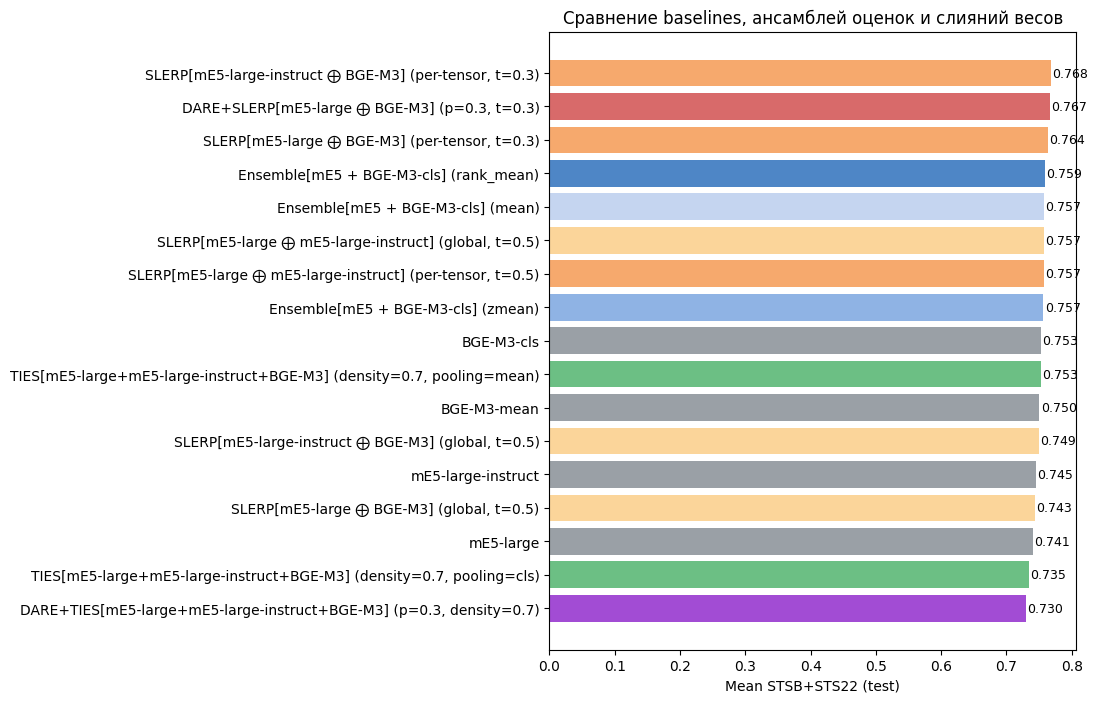

In [ ]:

# Визуализация
fig, ax = plt.subplots(figsize=(11, max(4, 0.42*len(df))))
colors = {
    "baseline":           "#9aa0a6",
    "score_ensemble_mean":"#c5d5f0",
    "score_ensemble_zmean":"#8fb3e4",
    "score_ensemble_rank_mean":"#4e86c6",
    "slerp_per_tensor":   "#f6a96d",
    "slerp_global":       "#fbd59a",
    "ties":               "#6cbf84",
    "dare_slerp":         "#d86a6a",
    "dare_ties":          "#a24cd4",
}
bar_colors = [colors.get(t, "#bbbbbb") for t in df["type"]]
ax.barh(df["model"][::-1], df["Mean"][::-1], color=bar_colors[::-1])
ax.set_xlabel("Mean STSB+STS22 (test)")
ax.set_title("Сравнение baselines, ансамблей оценок и слияний весов")
for i, (m, v) in enumerate(zip(df["model"][::-1], df["Mean"][::-1])):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


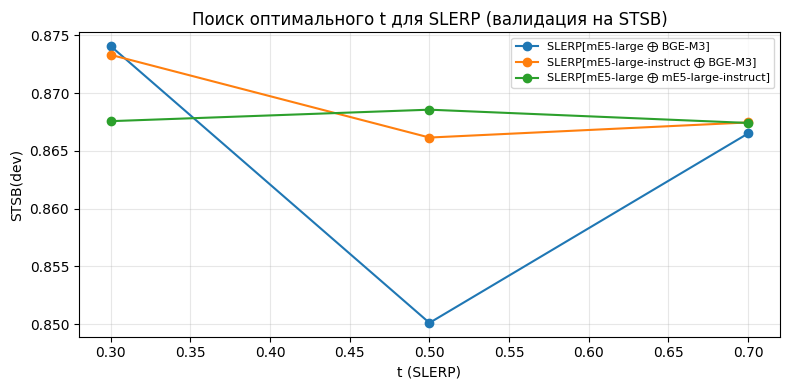

In [ ]:

# SLERP: график качества на валидации по t
slerp_per_tensor_runs = [r for r in slerp_rows if r.get("type") == "slerp_per_tensor" and "val_grid" in r]
if slerp_per_tensor_runs:
    fig, ax = plt.subplots(figsize=(8, 4))
    for r in slerp_per_tensor_runs:
        vg = r["val_grid"]
        xs = sorted(vg.keys())
        ys = [vg[x] for x in xs]
        ax.plot(xs, ys, marker="o", label=r["model"].split("]")[0] + "]")
    ax.set_xlabel("t (SLERP)"); ax.set_ylabel(f"STSB({STSB_VAL_SPLIT})")
    ax.set_title("Поиск оптимального t для SLERP (валидация на STSB)")
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc="best")
    plt.tight_layout(); plt.show()
